# Exercise 01 — Phân loại KNN trên lưới tọa độ 10×10

**Đề bài:** Cho 31 điểm huấn luyện thuộc 4 lớp (Tam giác đỏ, Vuông xanh, Sao xanh lá, Tim đen) và 6 điểm chưa gán nhãn A–F. Thực hiện phân loại KNN với các yêu cầu sau:

- **Câu a** — Với mỗi điểm A–F, tính khoảng cách tới toàn bộ 31 điểm gốc và phân loại bằng KNN, lặp lại cho 6 cấu hình `{Euclidean, Manhattan} × {k=4, k=5, k=6}` → 36 bảng chi tiết. Mỗi điểm A–F được phân loại **độc lập**, chỉ dựa trên 31 điểm huấn luyện gốc (không dùng nhãn vừa dự đoán của điểm khác).
- **Câu b** — Phân tích kết quả thay đổi thế nào khi tăng `k` và khi đổi metric.
- **Câu c** — Chương trình KNN from-scratch (verbose, không dùng sklearn)


## Dữ liệu trích xuất từ PDF

Tọa độ được dò bằng phân tích pixel theo màu (không đọc bằng mắt), sau đó vẽ lại để đối chiếu

| Lớp | Số điểm | Tọa độ |
|---|---|---|
| Tam giác đỏ | 8 | (3,1) (6,2) (1,2) (2,4) (6,5) (4,7) (3,9) (1,9) |
| Vuông xanh | 9 | (8,1) (9,2) (5,3) (8,3) (8,5) (1,7) (3,7) (7,8) (9,9) |
| Sao xanh lá | 5 | (2,1) (8,2) (4,4) (8,7) (4,8) |
| Tim đen | 9 | (5,1) (1,1) (2,2) (4,2) (1,3) (3,3) (2,5) (3,5) (4,5) |

**6 điểm cần phân loại:** A=(2,8), B=(6,7), C=(7,5), D=(2,3), E=(7,2), F=(4,1)

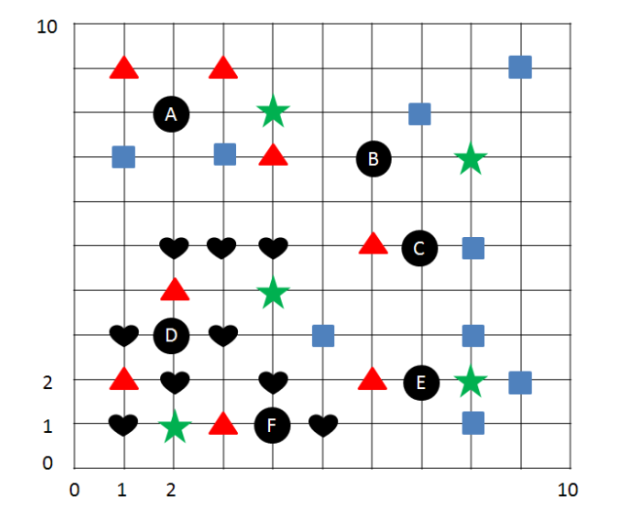


In [1]:
import math
import pandas as pd
from IPython.display import display, Markdown

TRAINING_DATA = [
    (3,1,"Tam giác đỏ"), (6,2,"Tam giác đỏ"), (1,2,"Tam giác đỏ"), (2,4,"Tam giác đỏ"),
    (6,5,"Tam giác đỏ"), (4,7,"Tam giác đỏ"), (3,9,"Tam giác đỏ"), (1,9,"Tam giác đỏ"),
    (8,1,"Vuông xanh"), (9,2,"Vuông xanh"), (5,3,"Vuông xanh"), (8,3,"Vuông xanh"),
    (8,5,"Vuông xanh"), (1,7,"Vuông xanh"), (3,7,"Vuông xanh"), (7,8,"Vuông xanh"), (9,9,"Vuông xanh"),
    (2,1,"Sao xanh lá"), (8,2,"Sao xanh lá"), (4,4,"Sao xanh lá"), (8,7,"Sao xanh lá"), (4,8,"Sao xanh lá"),
    (5,1,"Tim đen"), (1,1,"Tim đen"), (2,2,"Tim đen"), (4,2,"Tim đen"), (1,3,"Tim đen"),
    (3,3,"Tim đen"), (2,5,"Tim đen"), (3,5,"Tim đen"), (4,5,"Tim đen"),
]
assert len(TRAINING_DATA) == 31

QUERY_POINTS = {"A": (2,8), "B": (6,7), "C": (7,5), "D": (2,3), "E": (7,2), "F": (4,1)}

pd.set_option("display.max_rows", 40)


## Hàm khoảng cách & thuật toán KNN (from scratch)

In [2]:
def euclidean_distance(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

def manhattan_distance(p1, p2):
    return abs(p1[0]-p2[0]) + abs(p1[1]-p2[1])


def knn_classify(query_point, k, metric="euclidean", training_data=None):
    if training_data is None:
        training_data = TRAINING_DATA
    dist_func = euclidean_distance if metric == "euclidean" else manhattan_distance

    distances = []
    for (x, y, label) in training_data:
        distances.append({"point": (x, y), "label": label,
                           "distance": dist_func(query_point, (x, y))})
    distances.sort(key=lambda item: item["distance"])   # tăng dần

    neighbors = distances[:k]

    vote_count = {}
    for n in neighbors:
        vote_count[n["label"]] = vote_count.get(n["label"], 0) + 1

    max_votes = max(vote_count.values())
    tied_labels = [lab for lab, c in vote_count.items() if c == max_votes]
    tie_broken = len(tied_labels) > 1

    if not tie_broken:
        predicted_label = tied_labels[0]
    else:
        best_label, best_dist = None, float("inf")
        for n in neighbors:
            if n["label"] in tied_labels and n["distance"] < best_dist:
                best_dist, best_label = n["distance"], n["label"]
        predicted_label = best_label

    return {
        "query_point": query_point, "k": k, "metric": metric,
        "sorted_distances": distances, "neighbors": neighbors,
        "vote_count": vote_count,
        "tied_labels": tied_labels if tie_broken else None,
        "tie_broken": tie_broken, "predicted_label": predicted_label,
    }


## Câu a — 36 bảng phân loại chi tiết

Với mỗi điểm A–F, với mỗi cấu hình (metric, k), bảng dưới liệt kê **toàn bộ 31 điểm huấn luyện**, khoảng cách đã sắp xếp tăng dần, và đánh dấu k điểm gần nhất (cột "Trong k-NN?").

In [3]:
ks = [4, 5, 6]
metrics = ["euclidean", "manhattan"]
all_results = {}

for name, coord in QUERY_POINTS.items():
    for metric in metrics:
        for k in ks:
            result = knn_classify(coord, k, metric)
            all_results[(name, metric, k)] = result

            df = pd.DataFrame([
                {
                    "STT": i + 1,
                    "Điểm huấn luyện": str(item["point"]),
                    "Nhãn": item["label"],
                    "Khoảng cách": round(item["distance"], 4),
                    "Trong k-NN?": "✓" if i < k else "",
                }
                for i, item in enumerate(result["sorted_distances"])
            ])

            tie_note = ""
            if result["tie_broken"]:
                tie_note = f"  ⚠️ Hoà phiếu giữa **{result['tied_labels']}** → phá hoà bằng láng giềng gần nhất"

            display(Markdown(f"### Điểm {name} = {coord} | k = {k} | metric = {metric}{tie_note}"))
            display(df)
            display(Markdown(f"**Phân phối phiếu bầu:** `{result['vote_count']}` &nbsp;→&nbsp; **Nhãn dự đoán: {result['predicted_label']}**"))
            display(Markdown("---"))


### Điểm A = (2, 8) | k = 4 | metric = euclidean  ⚠️ Hoà phiếu giữa **['Tam giác đỏ', 'Vuông xanh']** → phá hoà bằng láng giềng gần nhất

,STT,Điểm huấn luyện,Nhãn,Khoảng cách,Trong k-NN?
0,1,"(3, 9)",Tam giác đỏ,1.4142,✓
1,2,"(1, 9)",Tam giác đỏ,1.4142,✓
2,3,"(1, 7)",Vuông xanh,1.4142,✓
3,4,"(3, 7)",Vuông xanh,1.4142,✓
4,5,"(4, 8)",Sao xanh lá,2.0000,
5,6,"(4, 7)",Tam giác đỏ,2.2361,
6,7,"(2, 5)",Tim đen,3.0000,
7,8,"(3, 5)",Tim đen,3.1623,
8,9,"(4, 5)",Tim đen,3.6056,
9,10,"(2, 4)",Tam giác đỏ,4.0000,


**Phân phối phiếu bầu:** `{'Tam giác đỏ': 2, 'Vuông xanh': 2}` &nbsp;→&nbsp; **Nhãn dự đoán: Tam giác đỏ**

---

### Điểm A = (2, 8) | k = 5 | metric = euclidean  ⚠️ Hoà phiếu giữa **['Tam giác đỏ', 'Vuông xanh']** → phá hoà bằng láng giềng gần nhất

...

---

### Điểm F = (4, 1) | k = 6 | metric = manhattan  ⚠️ Hoà phiếu giữa **['Tam giác đỏ', 'Tim đen']** → phá hoà bằng láng giềng gần nhất

,STT,Điểm huấn luyện,Nhãn,Khoảng cách,Trong k-NN?
0,1,"(3, 1)",Tam giác đỏ,1,✓
1,2,"(5, 1)",Tim đen,1,✓
2,3,"(4, 2)",Tim đen,1,✓
3,4,"(2, 1)",Sao xanh lá,2,✓
4,5,"(6, 2)",Tam giác đỏ,3,✓
5,6,"(5, 3)",Vuông xanh,3,✓
6,7,"(4, 4)",Sao xanh lá,3,
7,8,"(1, 1)",Tim đen,3,
8,9,"(2, 2)",Tim đen,3,
9,10,"(3, 3)",Tim đen,3,


**Phân phối phiếu bầu:** `{'Tam giác đỏ': 2, 'Tim đen': 2, 'Sao xanh lá': 1, 'Vuông xanh': 1}` &nbsp;→&nbsp; **Nhãn dự đoán: Tam giác đỏ**

---

## Bảng tổng hợp (6 điểm × 6 cấu hình) — dùng cho câu b

In [4]:
rows = []
for name in QUERY_POINTS:
    row = {"Điểm": name, "Toạ độ": str(QUERY_POINTS[name])}
    for metric in metrics:
        for k in ks:
            r = all_results[(name, metric, k)]
            tag = r["predicted_label"] + (" ⚠️(hoà)" if r["tie_broken"] else "")
            row[f"{metric} k={k}"] = tag
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("Điểm")
summary_df


,Toạ độ,euclidean k=4,euclidean k=5,euclidean k=6,manhattan k=4,manhattan k=5,manhattan k=6
Điểm,,,,,,,
A,"(2, 8)",Tam giác đỏ ⚠️(hoà),Tam giác đỏ ⚠️(hoà),Tam giác đỏ,Tam giác đỏ ⚠️(hoà),Tam giác đỏ ⚠️(hoà),Tam giác đỏ
B,"(6, 7)",Tam giác đỏ,Tam giác đỏ ⚠️(hoà),Vuông xanh ⚠️(hoà),Tam giác đỏ,Tam giác đỏ ⚠️(hoà),Tam giác đỏ ⚠️(hoà)
C,"(7, 5)",Vuông xanh,Vuông xanh,Vuông xanh,Vuông xanh,Vuông xanh,Vuông xanh
D,"(2, 3)",Tim đen,Tim đen,Tim đen,Tim đen,Tim đen,Tim đen
E,"(7, 2)",Vuông xanh,Vuông xanh,Vuông xanh,Vuông xanh,Vuông xanh,Vuông xanh
F,"(4, 1)",Tim đen,Tam giác đỏ ⚠️(hoà),Tam giác đỏ ⚠️(hoà),Tim đen,Tam giác đỏ ⚠️(hoà),Tam giác đỏ ⚠️(hoà)


## Câu b — Phân tích ảnh hưởng của k và của loại khoảng cách

*(Nhận xét dưới đây dựa trực tiếp trên bảng tổng hợp ở trên, đã chạy và kiểm chứng bằng code.)*

**Nhóm điểm ổn định (không đổi qua cả 6 cấu hình): C, D, E**
- C → Vuông xanh, D → Tim đen, E → Vuông xanh ở mọi k ∈ {4,5,6} và cả 2 metric, không hoà phiếu lần nào.
- Đây là các điểm nằm sâu trong vùng ảnh hưởng của một lớp duy nhất (láng giềng gần nhất đa số áp đảo), nên việc tăng k (thêm vài láng giềng xa hơn) hay đổi cách đo khoảng cách không đủ để lật kết quả.

**Điểm A — ổn định nhãn nhưng có hoà phiếu ở k nhỏ**
- Luôn dự đoán là Tam giác đỏ ở cả 6 cấu hình.
- Ở k=4 và k=5 xảy ra hoà 2–2 giữa *Tam giác đỏ* và *Vuông xanh* (4 láng giềng gần nhất của A đối xứng: 2 điểm tam giác đỏ và 2 điểm vuông xanh cách đều A ở cả 2 metric) → được phá hoà nghiêng về Tam giác đỏ vì đây là lớp xuất hiện trước trong danh sách đã sắp xếp khi khoảng cách bằng tuyệt đối. Ở k=6, thêm 1 điểm Tam giác đỏ nữa nên đa số rõ ràng, hết hoà.
- Vì các điểm gây hoà cách đều A theo *cả* Euclidean lẫn Manhattan (grid nguyên, lệch (1,1)), nên đổi metric không ảnh hưởng đến A.

**Điểm B — nhạy nhất với cả k lẫn metric**
- k=4, k=5 (cả 2 metric): dự đoán Tam giác đỏ (ở k=5 có hoà 2–2 với Vuông xanh/Sao xanh lá tuỳ metric nhưng vẫn phá hoà về Tam giác đỏ).
- k=6: **Euclidean chuyển sang Vuông xanh**, trong khi **Manhattan vẫn giữ Tam giác đỏ**. Ở k=6 xuất hiện hoà 3 lớp (Vuông xanh / Tam giác đỏ / Sao xanh lá đều 2 phiếu); quy tắc phá hoà chọn theo láng giềng gần nhất, và **thứ hạng "ai gần nhất" đổi chỗ tuỳ theo metric** — đây là ví dụ rõ nhất cho thấy Euclidean và Manhattan có thể xếp hạng khoảng cách khác nhau khi các điểm không nằm trên cùng trục hoặc đường chéo 45°.
- Kết luận: B nằm ở vùng ranh giới giữa 3 lớp nên rất nhạy với k và với cách đo khoảng cách.

**Điểm F — thay đổi khi tăng k, nhưng ổn định giữa 2 metric**
- k=4: đa số rõ ràng là Tim đen (2 phiếu so với 1-1 của Tam giác đỏ và Sao xanh lá).
- k=5, k=6 (cả 2 metric): thêm 1 láng giềng Tam giác đỏ → hoà 2–2 với Tim đen → phá hoà nghiêng về **Tam giác đỏ** (láng giềng tam giác đỏ gần nhất đứng trước trong danh sách sắp xếp khi khoảng cách bằng nhau tuyệt đối giữa hai lớp).
- Ở đây tăng k làm **lật kết quả** (Tim đen → Tam giác đỏ), nhưng đổi metric không ảnh hưởng vì thứ hạng láng giềng của F giống hệt nhau ở cả 2 cách đo.

**Nhận xét tổng quát**
- *Ảnh hưởng của k*: k nhỏ dễ bị chi phối bởi 1–2 láng giềng gần nhất (dễ có đa số rõ ràng nhưng cũng dễ hoà nếu các lớp phân bố đối xứng); tăng k đưa thêm điểm ở xa vào, có thể làm rõ hơn xu hướng đa số (A) hoặc gây lật nhãn nếu điểm mới thuộc một lớp cạnh tranh (B, F).
- *Ảnh hưởng của metric*: trên lưới nguyên này, phần lớn các cặp điểm cách đều nhau theo cả Euclidean lẫn Manhattan (lệch theo trục hoặc đường chéo 45°) nên hai metric thường cho cùng kết quả (A, C, D, E, F giống nhau ở mọi k). Khác biệt chỉ xuất hiện ở B (k=6) — nơi việc phá hoà phụ thuộc vào thứ hạng khoảng cách chi tiết, và Manhattan/Euclidean xếp hạng khác nhau với các điểm lệch không đối xứng theo trục.
- *Điểm biên vs điểm lõi*: các điểm nằm gần ranh giới nhiều lớp (**B, F**) nhạy cảm với lựa chọn k/metric hơn hẳn so với các điểm nằm sâu trong vùng một lớp (**C, D, E**). A là trường hợp trung gian: có hoà phiếu nhưng nhờ tính đối xứng hình học nên nhãn cuối cùng vẫn ổn định.

## Câu c — Đối chiếu nhanh với chương trình `knn_cau_c.py`

Chương trình đầy đủ (in từng bước: bảng khoảng cách → k láng giềng → phân phối phiếu bầu → nhãn dự đoán, cộng chế độ nhập tương tác) nằm ở file **`knn_cau_c.py`** đi kèm, đúng theo yêu cầu đề bài là một *chương trình Python* độc lập.

Cell dưới đây chỉ chạy lại đúng demo bắt buộc của đề (**điểm E, k=5, cả 2 metric**) để đối chiếu kết quả với file `.py`.

In [5]:
for metric in ["euclidean", "manhattan"]:
    r = knn_classify(QUERY_POINTS["E"], 5, metric)
    print(f"[{metric}] E={QUERY_POINTS['E']}  k=5  -> vote={r['vote_count']}  predicted={r['predicted_label']}")


[euclidean] E=(7, 2)  k=5  -> vote={'Tam giác đỏ': 1, 'Sao xanh lá': 1, 'Vuông xanh': 3}  predicted=Vuông xanh
[manhattan] E=(7, 2)  k=5  -> vote={'Tam giác đỏ': 1, 'Sao xanh lá': 1, 'Vuông xanh': 3}  predicted=Vuông xanh
